# Lab Experiment 2: Data Pre-Processing

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [13]:
# Creating a DataFrame
data = {
    'Name': ['Aarav', 'Rohan', 'Kunal', 'Vikram', 'Aarav', 'Neha', 'Suresh', 'Pooja', 'Anita', 'Rahul'],
    'Age': [25, 30, 35, 40, 25, 22, np.nan, 29, 30, 31],
    'Salary': [50000, 60000, 70000, 80000, 50000, 45000, 52000, 58000, 61000, 63000],
    'Score': [85, 90, 95, np.nan, 85, 88, 92, 89, 91, 87],
    'Height': [165, 170, 175, 180, 165, 160, 172, 168, 171, 173],
    'Weight': [60, 70, 80, 90, 60, 55, 75, 65, 72, 74]
}
df = pd.DataFrame(data)
df

,Name,Age,Salary,Score,Height,Weight
0,Aarav,25.0,50000,85.0,165,60
1,Rohan,30.0,60000,90.0,170,70
2,Kunal,35.0,70000,95.0,175,80
3,Vikram,40.0,80000,NaN,180,90
4,Aarav,25.0,50000,85.0,165,60
5,Neha,22.0,45000,88.0,160,55
6,Suresh,NaN,52000,92.0,172,75
7,Pooja,29.0,58000,89.0,168,65
8,Anita,30.0,61000,91.0,171,72
9,Rahul,31.0,63000,87.0,173,74


In [14]:
# Data Cleaning: Handling Missing Values
print("Original Shape:", df.shape)
df_cleaned = df.dropna()
print("Shape after dropping missing values:", df_cleaned.shape)
# Re-index after dropna is good practice but keeping it simple as requested
df_cleaned

Original Shape: (10, 6)
Shape after dropping missing values: (8, 6)


,Name,Age,Salary,Score,Height,Weight
0,Aarav,25.0,50000,85.0,165,60
1,Rohan,30.0,60000,90.0,170,70
2,Kunal,35.0,70000,95.0,175,80
4,Aarav,25.0,50000,85.0,165,60
5,Neha,22.0,45000,88.0,160,55
7,Pooja,29.0,58000,89.0,168,65
8,Anita,30.0,61000,91.0,171,72
9,Rahul,31.0,63000,87.0,173,74


In [15]:
# Data Integration: Removing Duplicates
# Note: In our synthetic data, row 0 and row 4 are identical ('Alice', 25, ...)
df_no_duplicates = df_cleaned.drop_duplicates()
print("Shape after removing duplicates:", df_no_duplicates.shape)
df_no_duplicates

Shape after removing duplicates: (7, 6)


,Name,Age,Salary,Score,Height,Weight
0,Aarav,25.0,50000,85.0,165,60
1,Rohan,30.0,60000,90.0,170,70
2,Kunal,35.0,70000,95.0,175,80
5,Neha,22.0,45000,88.0,160,55
7,Pooja,29.0,58000,89.0,168,65
8,Anita,30.0,61000,91.0,171,72
9,Rahul,31.0,63000,87.0,173,74


In [16]:
# Data Transformation: Normalization (Min-Max Scaling)
scaler = MinMaxScaler()
df_normalized = df_no_duplicates.copy()
# Transforming numerical columns
cols_to_scale = ['Age', 'Salary', 'Score', 'Height', 'Weight']
df_normalized[cols_to_scale] = scaler.fit_transform(df_normalized[cols_to_scale])
df_normalized.head()

,Name,Age,Salary,Score,Height,Weight
0,Aarav,0.230769,0.20,0.0,0.333333,0.2
1,Rohan,0.615385,0.60,0.5,0.666667,0.6
2,Kunal,1.000000,1.00,1.0,1.000000,1.0
5,Neha,0.000000,0.00,0.3,0.000000,0.0
7,Pooja,0.538462,0.52,0.4,0.533333,0.4


In [17]:
# Data Transformation: Standardization (Z-Score)
scaler_z = StandardScaler()
df_zscore = df_no_duplicates.copy()
df_zscore[cols_to_scale] = scaler_z.fit_transform(df_zscore[cols_to_scale])
df_zscore.head()

,Name,Age,Salary,Score,Height,Weight
0,Aarav,-0.987218,-1.057734,-1.446728,-0.820067,-1.006764
1,Rohan,0.292509,0.241238,0.241121,0.242983,0.251691
2,Kunal,1.572236,1.540209,1.928971,1.306032,1.510147
5,Neha,-1.755054,-1.707220,-0.434019,-1.883116,-1.635992
7,Pooja,0.036564,-0.018557,-0.096449,-0.182237,-0.377537


In [18]:
# Data Smoothening: Binning
# Let's bin 'Age' into categories
bins = [0, 30, 40, 100]
labels = ['Young', 'Middle-aged', 'Senior']
df_binned = df_no_duplicates.copy()
df_binned['Age_Group'] = pd.cut(df_binned['Age'], bins=bins, labels=labels)
df_binned[['Age', 'Age_Group']]

,Age,Age_Group
0,25.0,Young
1,30.0,Young
2,35.0,Middle-aged
5,22.0,Young
7,29.0,Young
8,30.0,Young
9,31.0,Middle-aged


In [19]:
# Data Reduction: PCA
# Using all numerical features to reduce to 2 components
pca = PCA(n_components=2)
features = df_no_duplicates[cols_to_scale]
pca_result = pca.fit_transform(features)
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca.head()

,PC1,PC2
0,-8142.863698,-2.286174
1,1857.144750,0.163469
2,11857.153197,2.613111
3,-13142.868156,2.454974
4,-142.860599,0.448351


## Theory: Pearson Correlation

In [20]:
# Pearson Correlation: NumPy Implementation
# Using Height and Weight as example
height = df_no_duplicates['Height']
weight = df_no_duplicates['Weight']
correlation_matrix_np = np.corrcoef(height, weight)
print("Correlation Matrix (NumPy):\n", correlation_matrix_np)

Correlation Matrix (NumPy):
 [[1.         0.98614993]
 [0.98614993 1.        ]]


In [21]:
# Pearson Correlation: Pandas Implementation
correlation_matrix_pd = df_no_duplicates[['Height', 'Weight']].corr(method='pearson')
print("Correlation Matrix (Pandas):\n", correlation_matrix_pd)

Correlation Matrix (Pandas):
          Height   Weight
Height  1.00000  0.98615
Weight  0.98615  1.00000


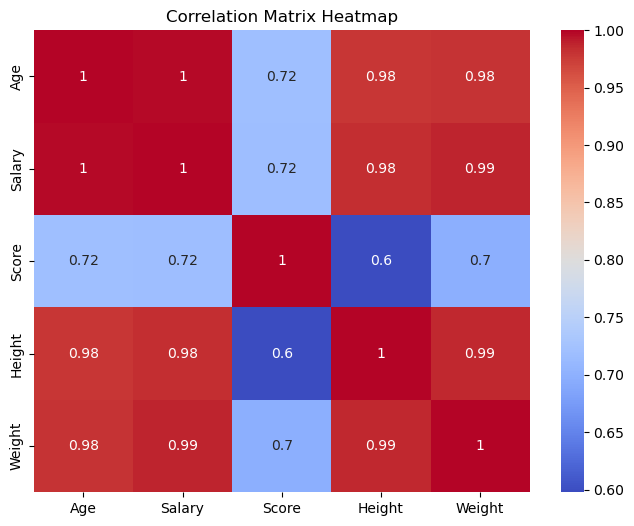

In [22]:
# Visualization: Heatmap of Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df_no_duplicates[cols_to_scale].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

## Conclusion

Data preprocessing is a critical step in the data mining process. It involves cleaning, integrating, transforming, and reducing data to make it suitable for analysis. In this lab, we successfully demonstrated techniques for handling missing values, removing duplicates, normalizing data using Min-Max and Z-score methods, binning for data smoothing, and applying PCA for dimensionality reduction. We also explored correlation analysis using Pearson's method and visualized the relationships using heatmaps.

## FAQs

1. **Why do we need scaling?**
   Scaling ensures that features with different units and ranges contribute equally to the analysis, preventing features with larger magnitudes from dominating the model.

2. **Benefits and Techniques of Binning in Python**
   Binning smooths noisy data, handles outliers, and can improve model performance by grouping continuous values into discrete categories. Techniques include equal-width binning and equal-frequency binning.

3. **What is Data leakage, how to avoid any data leakage during the model testing process.**
   Data leakage occurs when information from the target variable is used to train the model. To avoid it, ensure that data preprocessing (like scaling) is fit only on the training set and then applied to the test set.

4. **Which technique we should use Normalization or Standardization?**
   Normalization (Min-Max) is useful when the data needs to be bounded (e.g., 0-1) and for algorithms like Neural Networks. Standardization (Z-score) is better when the data follows a Gaussian distribution and for algorithms like SVMs and Logistic Regression.

5. **What are the benefits of Correlation Analysis?**
   It helps in identifying relationships between variables, detecting multicollinearity, and selecting relevant features for the model.

6. **What is the significance of Correlation Analysis?**
   It quantifies the strength and direction of the linear relationship between two variables, aiding in understanding data structure and feature selection.

7. **What are the different kinds of correlation analysis? Discuss their strength and weakness.**
   - **Pearson:** Measures linear relationship. Sensitive to outliers.
   - **Spearman:** Measures monotonic relationship. Robust to outliers but less powerful for linear relationships.
   - **Kendall:** Measures ordinal association. computationally expensive but robust.

8. **What are the factors that affect a Correlation Analysis?**
   Outliers, non-linear relationships, restricted range of data, and heterogeneous subgroups can affect correlation analysis.

9. **Write a short note on**
   - **a. The correlation coefficient:** A statistical measure (r) that calculates the strength of the relationship between the relative movements of two variables. It ranges from -1 to +1.
   - **b. The p-value:** A probability measure that helps determine the significance of the results. A low p-value (typically < 0.05) indicates that the observed correlation is statistically significant.